In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker

In [2]:
sp = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_ET_ratio_spatial.csv.gz", compression="gzip")
hpc = pd.read_csv("C:/Szonja/UNI/FYP/MantiShrimp-main - Copy/paramsweep_ET_ratio_summary.csv.gz", compression="gzip")

In [ ]:
ET_vals = sorted(hpc["E:T ratio"].unique())
x       = np.arange(len(ET_vals))
labels  = [str(v) for v in ET_vals]

def _agg(col):
    g = hpc.groupby("E:T ratio")[col]
    return g.mean().reindex(ET_vals).values, g.std().reindex(ET_vals).values

kills_mean,    kills_std    = _agg("kills")
eff_mean,      eff_std      = _agg("killing_efficiency")
kps_mean,      kps_std      = _agg("kills_per_synapse")
syn_mean,       syn_std     = _agg("synapses")
cpt_mean,      cpt_std      = _agg("contacts_per_target")

NK_counts = [
    int(hpc[hpc["E:T ratio"] == et]["Killer cell number"].iloc[0])
    for et in ET_vals
]

BLUE   = "#1022C5"
RED    = "#ff0000"
GREEN  = "#59A14F"
ORANGE = "#FF8C00"
PURPLE = "#8950BF"

def _style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.tick_params(axis="both", width=1.0, length=4)
    ax.grid(axis="y", linestyle="--", alpha=0.15)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)

def _errband(ax, means, stds, color, label, marker="o", ls="-"):
    ax.plot(x, means, color=color, linewidth=2.2, marker=marker,
            markersize=6, markeredgecolor="black", markeredgewidth=0.5,
            label=label, linestyle=ls, zorder=3)
    ax.fill_between(x, means - stds, means + stds,
                    color=color, alpha=0.12, zorder=1)

In [11]:

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BLUE   = "#1022C5"
RED    = "#ff0000"
GREEN  = "#59A14F"
ORANGE = "#FF8C00"
PURPLE = "#8950BF"

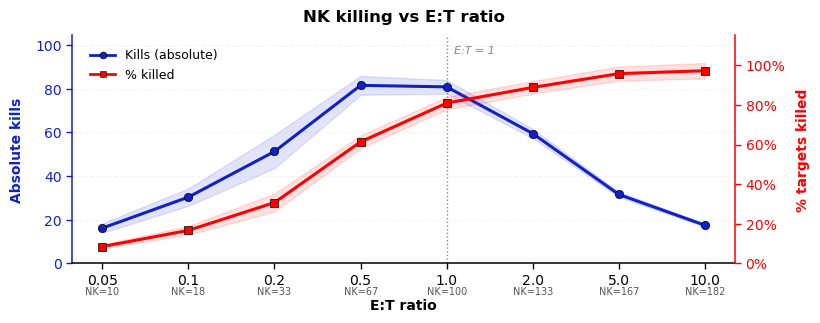

Saved: plot_ET_kills_dual.png


In [ ]:

# Figure 1 — Kills (absolute) + killing efficiency on dual axis


fig, ax1 = plt.subplots(figsize=(8.5, 6), facecolor="none")
ax1.set_facecolor("none")
fig.subplots_adjust(left=0.10, right=0.88, top=0.88, bottom=0.5)

ax2 = ax1.twinx()
ax2.set_facecolor("none")

# Absolute kills — left axis
_errband(ax1, kills_mean, kills_std, BLUE, "Kills (absolute)", marker="o")

# Killing efficiency — right axis
_errband(ax2, eff_mean * 100, eff_std * 100, RED, "% killed", marker="s")

# Annotate NK cell counts along bottom
for i, nk in enumerate(NK_counts):
    ax1.text(i, -kills_mean.max() * 0.13, f"NK={nk}",
             ha="center", va="top", fontsize=7, color="#555555",
             rotation=0)

ax1.set_ylim(0, kills_mean.max() * 1.28)
ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

ax1.set_ylabel("Absolute kills", fontweight="bold",
               labelpad=8, color=BLUE)
ax2.set_ylabel("% targets killed", fontweight="bold",
               labelpad=8, color=RED)
ax1.tick_params(axis="y", colors=BLUE, width=1.0, length=4)
ax2.tick_params(axis="y", colors=RED,  width=1.0, length=4)

ax1.set_xlabel("E:T ratio", fontweight="bold", labelpad=8)
ax1.set_title(
    "NK killing vs E:T ratio",
    fontweight="bold", pad=10,
)

_style_ax(ax1)
ax1.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_visible(False)
ax2.spines["right"].set_linewidth(1.1)
ax2.spines["right"].set_color(RED)
ax1.spines["left"].set_linewidth(1.1)
ax1.spines["left"].set_color(BLUE)
ax1.spines["bottom"].set_linewidth(1.1)

# Vertical line at E:T = 1
ax1.axvline(ET_vals.index(1.0), color="#888888", linewidth=1.0,
            linestyle=":", zorder=0)
ax1.text(ET_vals.index(1.0) + 0.08, kills_mean.max() * 1.18,
         "E:T = 1", fontsize=8, color="#888888", style="italic")

handles = [
    Line2D([0],[0], color=BLUE, linewidth=2, marker="o", markersize=5,
           markeredgecolor="black", markeredgewidth=0.4, label="Kills (absolute)"),
    Line2D([0],[0], color=RED,  linewidth=2, marker="s", markersize=5,
           markeredgecolor="black", markeredgewidth=0.4, label="% killed"),
]
ax1.legend(handles=handles, frameon=False, fontsize=9,
           loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.savefig("plot_ET_kills_dual.png", transparent=True, dpi=300, bbox_inches="tight")
plt.show()
print("Saved: plot_ET_kills_dual.png")

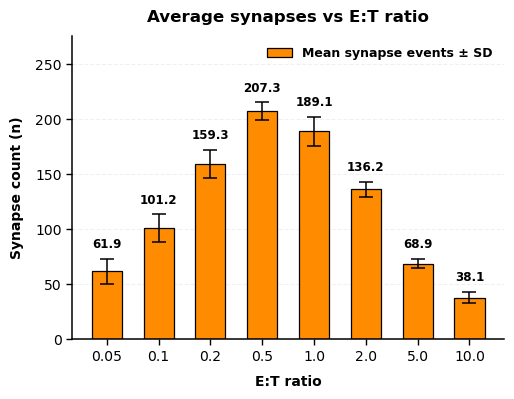

Saved: 3.1aplot_ET_synapses.png


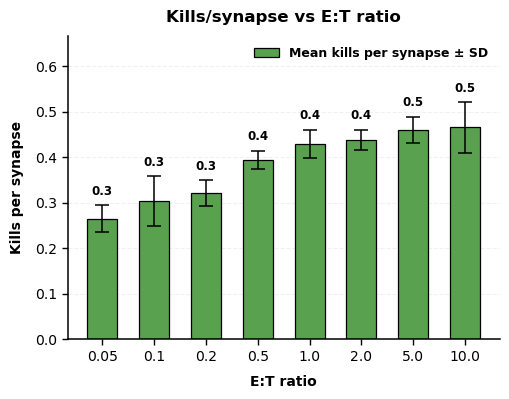

Saved: 3.1bplot_ET_killing_efficiency.png


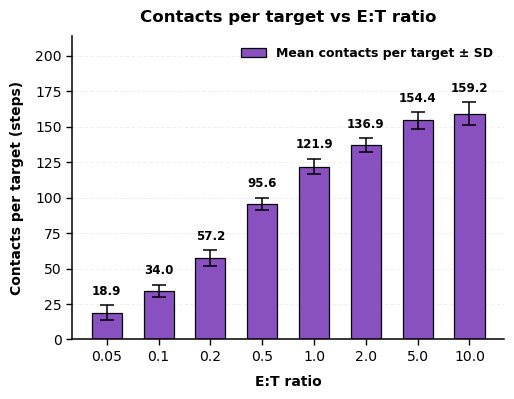

Saved: 3.1cplot_ET_contacts_per_target.png


In [18]:
panels = [
    (
        syn_mean, syn_std, ORANGE,
        "Mean synapse events ± SD",
        "Average synapses vs E:T ratio",
        "Synapse count (n)",
        "3.1aplot_ET_synapses.png"
    ),
    (
        kps_mean, kps_std, GREEN,
        "Mean kills per synapse ± SD",
        "Kills/synapse vs E:T ratio",
        "Kills per synapse",
        "3.1bplot_ET_killing_efficiency.png"
    ),
    (
        cpt_mean, cpt_std, PURPLE,
        "Mean contacts per target ± SD",
        "Contacts per target vs E:T ratio",
        "Contacts per target (steps)",
        "3.1cplot_ET_contacts_per_target.png"
    ),
]

for means, stds, col, lbl, title, ylabel, filename in panels:

    fig, ax = plt.subplots(figsize=(5.4, 4.6), facecolor="none")
    fig.subplots_adjust(left=0.16, right=0.96, top=0.84, bottom=0.18)

    ax.set_facecolor("none")

    y_max = (means + stds).max() * 1.28

    bars = ax.bar(
        x, means,
        yerr=stds,
        capsize=5,
        color=col,
        edgecolor="black",
        linewidth=0.9,
        width=0.58,
        error_kw=dict(lw=1.1, capthick=1.1, ecolor="black"),
        label=lbl,
        zorder=2,
    )

    ax.set_ylim(0, y_max)
    offset = y_max * 0.025

    for i, bar in enumerate(bars):
        h = bar.get_height()
        err = stds[i]

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + err + offset,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    ax.set_xlabel("E:T ratio", fontweight="bold", labelpad=8)
    ax.set_ylabel(ylabel, fontweight="bold", labelpad=8)
    ax.set_title(title, fontweight="bold", pad=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.1)
    ax.spines["bottom"].set_linewidth(1.1)

    ax.tick_params(axis="both", width=1.0, length=4)
    ax.grid(axis="y", linestyle="--", alpha=0.18)
    ax.set_axisbelow(True)

    leg = ax.legend(frameon=False, fontsize=9, loc="upper right")
    for t in leg.get_texts():
        t.set_fontweight("bold")

    plt.savefig(filename, transparent=True, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {filename}")